## Proeject 3: Web scraping and Price data extraction from Yfinace

### Object: At the end of this project, we should be able to do the following

* Install  & import the following Libraries ( Pandas, yfiance, requests, BeautifulSoup, and matplotlib)
* Write a Python code to extract stock price data from yfinace using requests, beautiful soup, and pandas libraries together
* Write a Python code to scrape table data from the web
* Clean data using pandas
* Plot stock data using the make_graph function


#### installing the needed libraries for the project

In [22]:
!pip install pandas
!pip install yfinance
!pip install requests
!pip install bs4
!pip install matplotlib
!pip install nbformat


In [22]:
import pandas as pd
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt


In [23]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

#### Question 1: Use yfinance to Extract Stock Data

In [29]:


# Download historical data for a stock

tesla = yf.Ticker("TSLA")

tesla_data = tesla.history(period="max") #cast data into a DataFrame and show the max price data available
tesla_data.reset_index(inplace=True)

# Display the downloaded data

tesla_data.head() #Display the top 5 rows

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


#####

#### Use web scraping to Extract Tesla Revenue Data

In [54]:
#SCRAPING THE DATA FROM THE WEB
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data = requests.get(URL).text #Download data from URL and save it as a text
soup = BeautifulSoup(html_data, "html.parser") #Parse the html data using beautiful_soup using parser
tesla_revenue = pd.read_html(html_data) #read the data from the html and cast into a dataframe
tesla_revenue = tesla_revenue[1] #locate the particular table on the website to scrape

#CLEANING THE DATA
tesla_revenue.columns = ["Date", "Revenue"] #Rename columns to Date and Revenue
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"",regex=True) #remove comman & dollar sign
tesla_revenue.dropna(inplace=True) #Remove all null values
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""] #Remove empty stringd

tesla_revenue.tail() #display the data


,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


#### Using yfinance to Extract GME price data

In [46]:
game_stop = yf.Ticker("GME")

gme_data = game_stop.history(period = "max")

gme_data.reset_index(inplace=True)



gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


#### Use web scraping to extract GameStop Revenue Data

In [74]:
#SCRAPING THE DATA FROM THE WEB
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_2 = requests.get(URL).text #Download data from the URL and store it as a text
sp = BeautifulSoup(html_data_2, "html.parser") #Parse data into HTML 
gme_revenue = pd.read_html(html_data_2) #read data using pandas
gme_revenue = gme_revenue[1] #Locate the table to scrape with the 1 index

#CLEANING THE DATA
gme_revenue.columns = ["Date", "Revenue"] #Rename columns
gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(',|\$',"",regex=True) #remove comma & dollar sign
gme_revenue.dropna(inplace = True) #drop all null values
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""] #remove empty strings

gme_revenue.tail() #display data


,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


#### Plot stock data using make graph function

In [70]:
def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

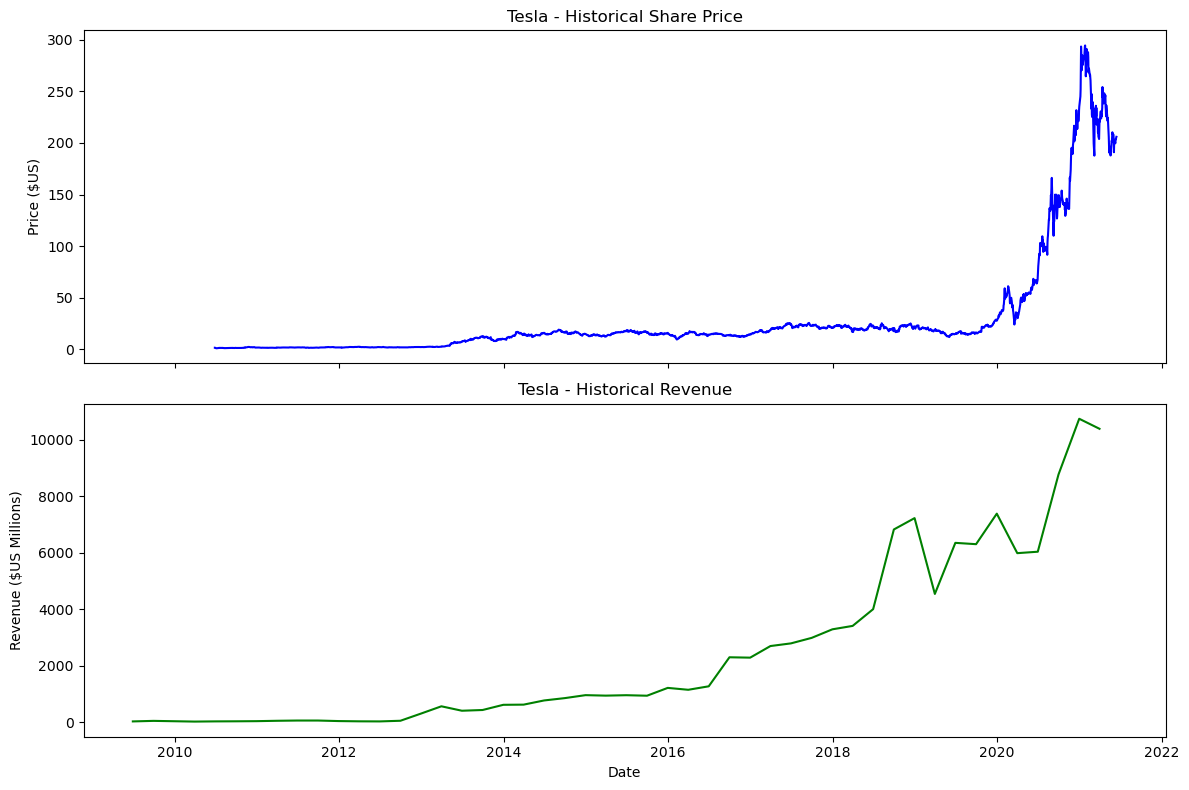

In [78]:
make_graph(tesla_data, tesla_revenue, 'Tesla')

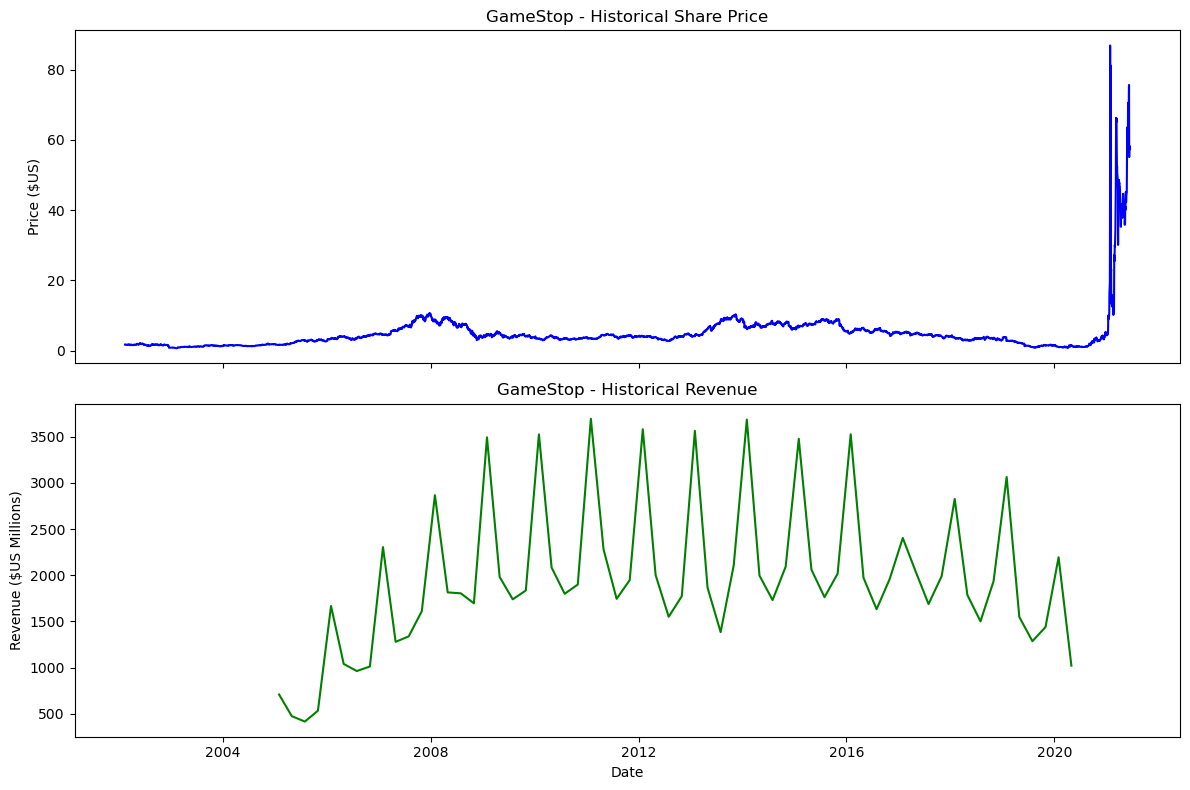

In [77]:
make_graph(gme_data, gme_revenue, 'GameStop')

#### Conclusion: 
In this project, I extracted Tesla and GameStop stock price data from Yahoo Finance and scraped their respective revenue from the web. clean the data. After that, I plotted their respective historical stock price and revenue on a line chart.

## Author:
### Shaibu Mahama Alhassan